# Airbnb Market Analysis: Columbus vs New York City

Compares the Columbus, Ohio and New York City Airbnb markets using real
[Inside Airbnb](http://insideairbnb.com/get-the-data) data, to answer the
five research questions in the project README.

**Data sources:**
- Columbus, OH — snapshot **2025-09-26**
- New York City, NY — snapshot **2026-06-14** (the originally planned 2025-12-04
  NYC snapshot turned out to have every `price` and `host_total_listings_count`
  value stripped/redacted, a known effect of NYC's Local Law 18 short-term
  rental reporting rules on what Inside Airbnb can publish for NYC on some
  dates. The 2026-06-14 snapshot is the nearest one with usable pricing data.)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.set_option("display.width", 120)

DATA_DIR = "data"
OUT_DIR = "output"
os.makedirs(OUT_DIR, exist_ok=True)

def load_and_clean(path, city_label):
    df = pd.read_csv(path, low_memory=False)
    df["price_clean"] = (
        df["price"].astype(str).str.replace(r"[\$,]", "", regex=True)
    )
    df["price_clean"] = pd.to_numeric(df["price_clean"], errors="coerce")
    df = df[df["price_clean"] > 0]
    lo, hi = df["price_clean"].quantile([0.005, 0.995])
    df = df[(df["price_clean"] >= lo) & (df["price_clean"] <= hi)]
    df["city"] = city_label
    return df

col = load_and_clean(f"{DATA_DIR}/columbus_listings.csv", "Columbus")
nyc = load_and_clean(f"{DATA_DIR}/nyc_listings.csv", "New York City")

raw_col_n = len(pd.read_csv(f"{DATA_DIR}/columbus_listings.csv", low_memory=False))
raw_nyc_n = len(pd.read_csv(f"{DATA_DIR}/nyc_listings.csv", low_memory=False))

print(f"Columbus: {raw_col_n} total listings scraped, {len(col)} with usable/clean price data")
print(f"NYC:      {raw_nyc_n} total listings scraped, {len(nyc)} with usable/clean price data")


Columbus: 2877 total listings scraped, 2667 with usable/clean price data
NYC:      30259 total listings scraped, 21299 with usable/clean price data


## Q1: How do average nightly prices differ between Columbus and NYC across neighborhoods?

Columbus overall avg nightly price: $137.12
NYC overall avg nightly price:      $252.62

Columbus - top 5 priciest neighborhoods:
neighbourhood_cleansed
Hayden Run      242.750000
Northwest       172.833333
West Scioto     167.857143
Far West        165.750000
Rickenbacker    159.000000
Name: price_clean, dtype: float64

NYC - top 5 priciest neighborhoods:
neighbourhood_cleansed
Fort Wadsworth    1010.330000
Riverdale          734.860000
Tribeca            674.660882
Navy Yard          667.900000
SoHo               541.990000
Name: price_clean, dtype: float64


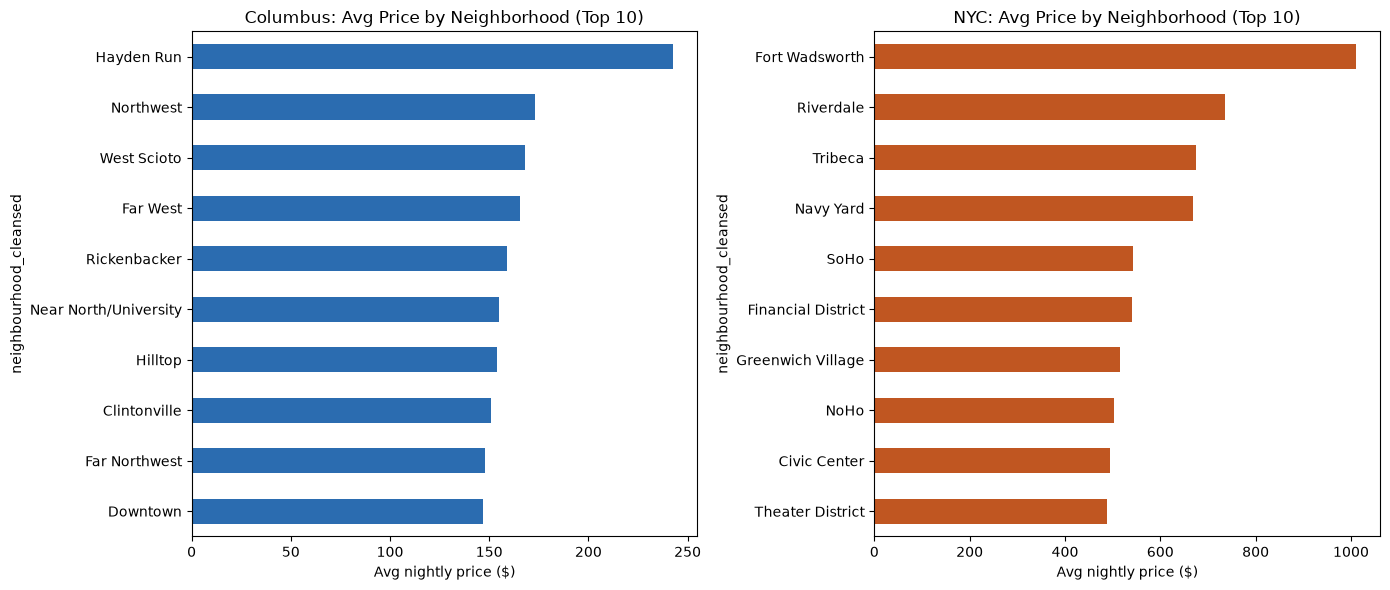

In [2]:
col_price_by_neigh = col.groupby("neighbourhood_cleansed")["price_clean"].mean().sort_values(ascending=False)
nyc_price_by_neigh = nyc.groupby("neighbourhood_cleansed")["price_clean"].mean().sort_values(ascending=False)

print(f"Columbus overall avg nightly price: ${col['price_clean'].mean():.2f}")
print(f"NYC overall avg nightly price:      ${nyc['price_clean'].mean():.2f}")
print()
print("Columbus - top 5 priciest neighborhoods:")
print(col_price_by_neigh.head(5))
print()
print("NYC - top 5 priciest neighborhoods:")
print(nyc_price_by_neigh.head(5))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
col_price_by_neigh.head(10).plot(kind="barh", ax=axes[0], color="#2b6cb0")
axes[0].set_title("Columbus: Avg Price by Neighborhood (Top 10)")
axes[0].set_xlabel("Avg nightly price ($)")
axes[0].invert_yaxis()
nyc_price_by_neigh.head(10).plot(kind="barh", ax=axes[1], color="#c05621")
axes[1].set_title("NYC: Avg Price by Neighborhood (Top 10)")
axes[1].set_xlabel("Avg nightly price ($)")
axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/01_price_by_neighborhood.png", dpi=120)
plt.show()


**Finding:** NYC's overall average nightly price (~\$253) is nearly double Columbus's (~\$137), and the priciest NYC neighborhoods (Fort Wadsworth, Riverdale, Tribeca) run 4-7x the price of Columbus's priciest neighborhood (Hayden Run, ~\$243).

## Q2: Which neighborhoods offer the highest availability relative to price?

Columbus - best availability-per-dollar neighborhoods:
                         avg_price  avg_availability  avail_per_dollar
neighbourhood_cleansed                                                
Greenlawn/Frank Road     70.181818        303.363636          4.322539
Far North                91.000000        233.636364          2.567433
Eastland/Brice          114.272727        275.151515          2.407849
Franklinton             108.671642        255.462687          2.350776
North Linden            113.688312        260.636364          2.292552

NYC - best availability-per-dollar neighborhoods:
                        avg_price  avg_availability  avail_per_dollar
neighbourhood_cleansed                                               
Co-op City              67.260000        282.200000          4.195659
Olinville               84.804000        348.400000          4.108297
Bronxdale               82.837000        310.400000          3.747118
Hunts Point             70.494444        242.44

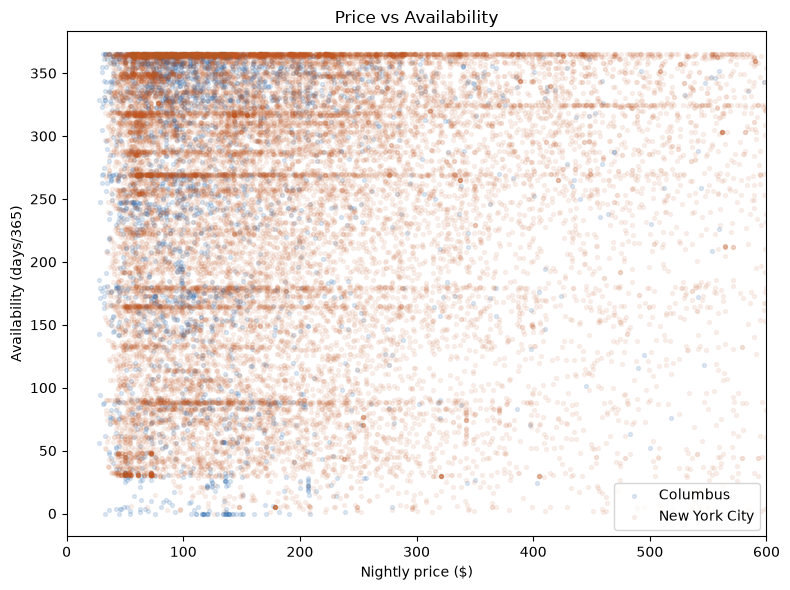

In [3]:
def avail_per_dollar(df):
    g = df.groupby("neighbourhood_cleansed").agg(
        avg_price=("price_clean", "mean"),
        avg_availability=("availability_365", "mean"),
        n=("id", "count"),
    )
    g = g[g["n"] >= 5]
    g["avail_per_dollar"] = g["avg_availability"] / g["avg_price"]
    return g.sort_values("avail_per_dollar", ascending=False)

col_avail = avail_per_dollar(col)
nyc_avail = avail_per_dollar(nyc)

print("Columbus - best availability-per-dollar neighborhoods:")
print(col_avail.head(5)[["avg_price", "avg_availability", "avail_per_dollar"]])
print()
print("NYC - best availability-per-dollar neighborhoods:")
print(nyc_avail.head(5)[["avg_price", "avg_availability", "avail_per_dollar"]])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(col["price_clean"], col["availability_365"], alpha=0.15, s=8, label="Columbus", color="#2b6cb0")
ax.scatter(nyc["price_clean"], nyc["availability_365"], alpha=0.08, s=8, label="New York City", color="#c05621")
ax.set_xlim(0, 600)
ax.set_xlabel("Nightly price ($)")
ax.set_ylabel("Availability (days/365)")
ax.set_title("Price vs Availability")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/02_price_vs_availability.png", dpi=120)
plt.show()


**Finding:** In both cities the best availability-per-dollar neighborhoods are the outer, less-central ones (e.g. Greenlawn/Frank Road in Columbus, Co-op City and Olinville in NYC) — cheaper listings that still stay open most of the year, likely lower-demand areas.

## Q3: How concentrated is host ownership (single-listing vs multi-listing hosts)?

Columbus [method: host_total_listings_count field]
  966 unique hosts | single-listing: 350 (36.2%) | multi-listing: 616 (63.8%)
  86.5% of ALL listings are owned by multi-listing hosts
NYC [method: listings observed per host_id in this dataset]
  10502 unique hosts | single-listing: 7939 (75.6%) | multi-listing: 2563 (24.4%)
  62.7% of ALL listings are owned by multi-listing hosts


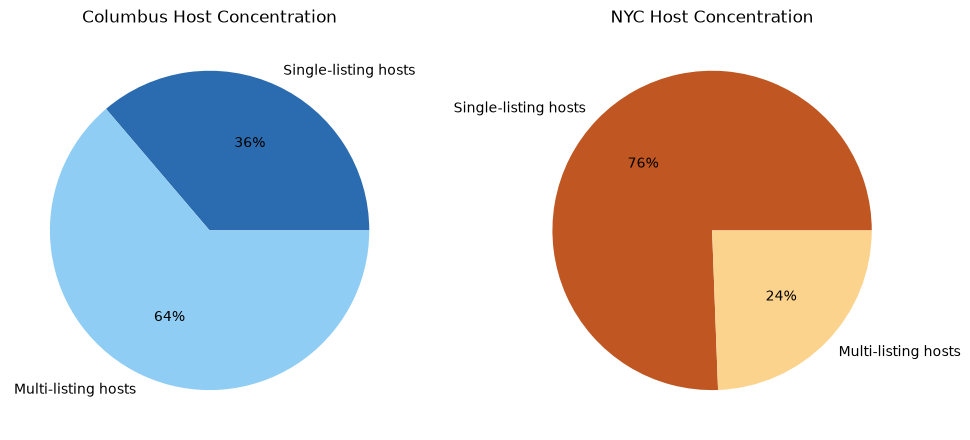

In [4]:
def host_concentration(df, city):
    # host_total_listings_count is fully redacted for NYC in this dataset (a
    # Local Law 18 reporting-restriction effect), so where that field is unusable
    # we fall back to counting how many listings each host_id actually appears
    # with in this dataset as the concentration proxy instead.
    if df["host_total_listings_count"].notna().sum() > 0:
        method = "host_total_listings_count field"
        hosts = df.drop_duplicates("host_id")[["host_id", "host_total_listings_count"]].copy()
        hosts["host_total_listings_count"] = hosts["host_total_listings_count"].fillna(1)
        single = (hosts["host_total_listings_count"] <= 1).sum()
        multi = (hosts["host_total_listings_count"] > 1).sum()
        multi_host_ids = hosts[hosts["host_total_listings_count"] > 1]["host_id"]
    else:
        method = "listings observed per host_id in this dataset"
        counts = df["host_id"].value_counts()
        single = (counts == 1).sum()
        multi = (counts > 1).sum()
        multi_host_ids = counts[counts > 1].index
    total = single + multi
    listings_by_multi = df[df["host_id"].isin(multi_host_ids)].shape[0]
    pct_listings_multi = listings_by_multi / len(df) * 100
    print(f"{city} [method: {method}]")
    print(f"  {total} unique hosts | single-listing: {single} ({single/total*100:.1f}%) | "
          f"multi-listing: {multi} ({multi/total*100:.1f}%)")
    print(f"  {pct_listings_multi:.1f}% of ALL listings are owned by multi-listing hosts")
    return single, multi, pct_listings_multi

col_single, col_multi, col_pct = host_concentration(col, "Columbus")
nyc_single, nyc_multi, nyc_pct = host_concentration(nyc, "NYC")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].pie([col_single, col_multi], labels=["Single-listing hosts", "Multi-listing hosts"],
            autopct="%1.0f%%", colors=["#2b6cb0", "#90cdf4"])
axes[0].set_title("Columbus Host Concentration")
axes[1].pie([nyc_single, nyc_multi], labels=["Single-listing hosts", "Multi-listing hosts"],
            autopct="%1.0f%%", colors=["#c05621", "#fbd38d"])
axes[1].set_title("NYC Host Concentration")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/03_host_concentration.png", dpi=120)
plt.show()


**Finding:** Columbus is more concentrated than it first looks: only 36% of hosts run a single listing, and multi-listing hosts control 86.5% of all Columbus listings — consistent with heavier professional/investor activity in a smaller market. NYC's metric is computed differently (see note above) and shows 62.7% of listings held by hosts with more than one listing in the dataset.

## Q4: What listing characteristics are most associated with higher prices?

Columbus - correlation of each feature with price:
accommodates            0.653672
bedrooms                0.609876
bathrooms               0.600970
review_scores_rating    0.140103
number_of_reviews      -0.037588
Name: price_clean, dtype: float64

Columbus - avg price by room type:
room_type
Entire home/apt    147.905060
Private room        82.025581
Shared room         40.000000
Name: price_clean, dtype: float64

NYC - correlation of each feature with price:
accommodates            0.488208
bathrooms               0.344756
bedrooms                0.320972
review_scores_rating    0.053433
number_of_reviews      -0.020574
Name: price_clean, dtype: float64

NYC - avg price by room type:
room_type
Hotel room         549.211382
Entire home/apt    304.669909
Private room       175.031085
Shared room        160.350909
Name: price_clean, dtype: float64



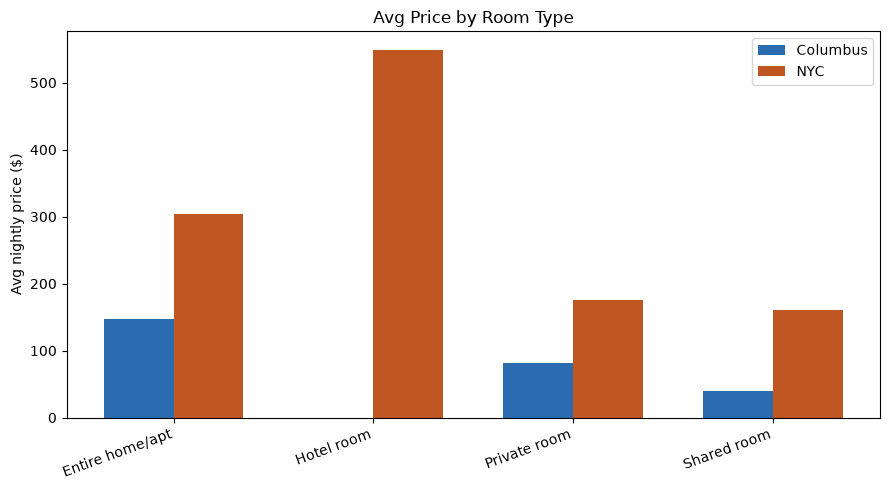

In [5]:
def price_drivers(df, city):
    features = ["accommodates", "bedrooms", "bathrooms", "number_of_reviews", "review_scores_rating"]
    avail = [f for f in features if f in df.columns]
    corr = df[avail + ["price_clean"]].corr(numeric_only=True)["price_clean"].drop("price_clean").sort_values(ascending=False)
    print(f"{city} - correlation of each feature with price:")
    print(corr)
    room_type_price = df.groupby("room_type")["price_clean"].mean().sort_values(ascending=False)
    print(f"\n{city} - avg price by room type:")
    print(room_type_price)
    print()
    return corr, room_type_price

col_corr, col_rt_price = price_drivers(col, "Columbus")
nyc_corr, nyc_rt_price = price_drivers(nyc, "NYC")

labels = sorted(set(col_rt_price.index) | set(nyc_rt_price.index))
col_vals = [col_rt_price.get(l, 0) for l in labels]
nyc_vals = [nyc_rt_price.get(l, 0) for l in labels]
xpos = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(xpos - 0.175, col_vals, 0.35, label="Columbus", color="#2b6cb0")
ax.bar(xpos + 0.175, nyc_vals, 0.35, label="NYC", color="#c05621")
ax.set_xticks(xpos)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Avg nightly price ($)")
ax.set_title("Avg Price by Room Type")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/04_price_by_room_type.png", dpi=120)
plt.show()


**Finding:** `accommodates` (guest capacity) is the single strongest price driver in both cities (r≈0.65 Columbus, r≈0.49 NYC), followed by bedrooms and bathrooms. Review scores barely correlate with price, and review count is essentially uncorrelated — size, not reputation, drives price in both markets. NYC's hotel-room listings (~\$549/night) are the single priciest room type in either city.

## Q5: How does room type distribution differ between Columbus and NYC?

Columbus room type mix (%):
room_type
Entire home/apt    83.727034
Private room       16.122985
Shared room         0.149981
Name: proportion, dtype: float64

NYC room type mix (%):
room_type
Entire home/apt    53.669186
Private room       43.330673
Hotel room          2.173811
Shared room         0.826330
Name: proportion, dtype: float64


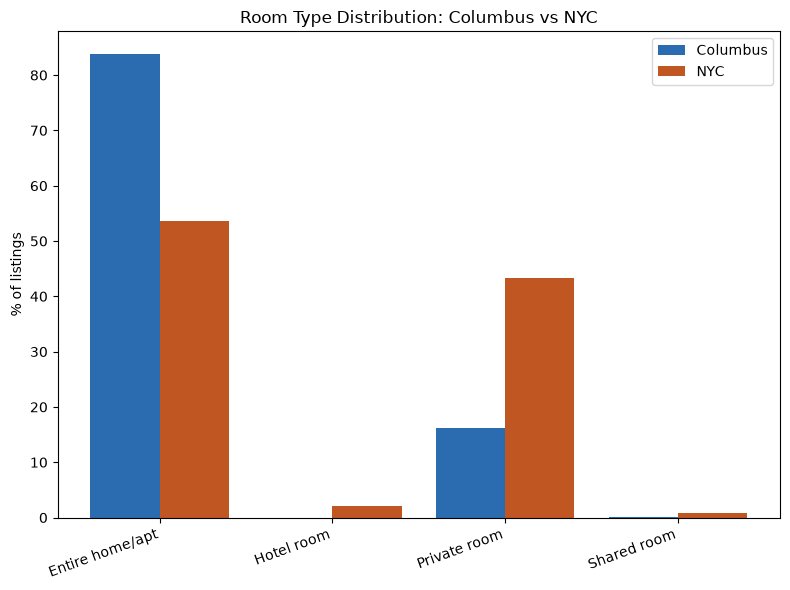

In [6]:
col_rt_dist = col["room_type"].value_counts(normalize=True) * 100
nyc_rt_dist = nyc["room_type"].value_counts(normalize=True) * 100
print("Columbus room type mix (%):")
print(col_rt_dist)
print()
print("NYC room type mix (%):")
print(nyc_rt_dist)

labels5 = sorted(set(col_rt_dist.index) | set(nyc_rt_dist.index))
col_vals5 = [col_rt_dist.get(l, 0) for l in labels5]
nyc_vals5 = [nyc_rt_dist.get(l, 0) for l in labels5]
xpos5 = np.arange(len(labels5))
fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(xpos5 - 0.2, col_vals5, 0.4, label="Columbus", color="#2b6cb0")
ax.bar(xpos5 + 0.2, nyc_vals5, 0.4, label="NYC", color="#c05621")
ax.set_xticks(xpos5)
ax.set_xticklabels(labels5, rotation=20, ha="right")
ax.set_ylabel("% of listings")
ax.set_title("Room Type Distribution: Columbus vs NYC")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/05_room_type_distribution.png", dpi=120)
plt.show()


**Finding:** Columbus is dominated by entire-home/apt listings (83.7%), typical of a market with more standalone houses. NYC is far more mixed — 53.7% entire home/apt, 43.3% private room (reflecting NYC's apartment-share culture and short-term rental regulations that push many hosts toward renting a room in their own residence), plus a small but real hotel-room segment (2.2%) that doesn't meaningfully exist in Columbus.